# Power System Load Type Prediction
Objective: Develop a machine learning model to predict the `Load_Type` (Light_Load, Medium_Load, Maximum_Load) of a power system based on historical energy consumption and temporal data.

## 1. Setup and Data Ingestion
Importing essential libraries for data manipulation, visualization, and modeling.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('load_data.csv')
df.columns = df.columns.str.strip()
df['Date_Time'] = pd.to_datetime(df['Date_Time'], dayfirst=True, format='mixed')

## 2. Exploratory Data Analysis (EDA)
Before engineering features or training the model, we need to understand the relationships between our continuous variables and the target variable (`Load_Type`).Specifically, we will look at how energy usage (`Usage_kWh`) changes throughout the day (`NSM` - Number of Seconds from midnight) across different load types.

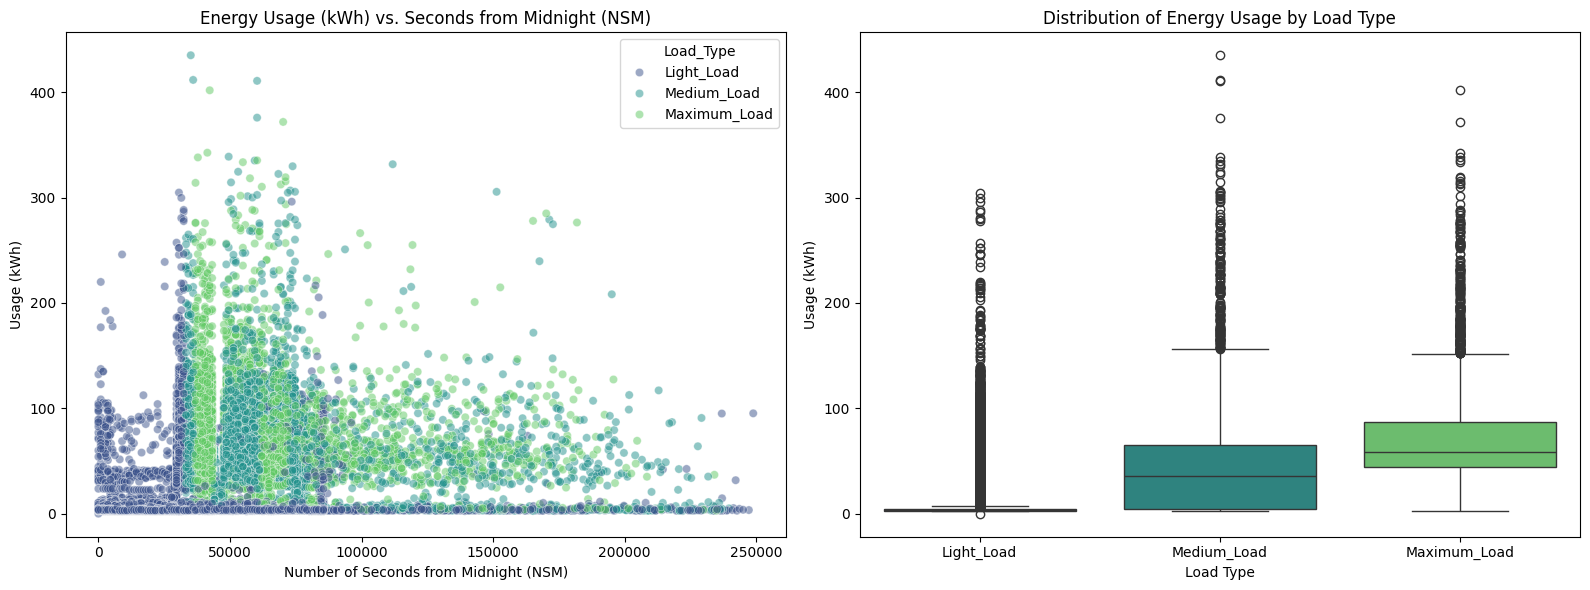

In [8]:
plt.figure(figsize=(16, 6))

# Plot 1: Usage vs. Time of Day (NSM) categorized by Load Type
plt.subplot(1, 2, 1)
sns.scatterplot(x='NSM', y='Usage_kWh', hue='Load_Type', data=df, alpha=0.5, palette='viridis')
plt.title('Energy Usage (kWh) vs. Seconds from Midnight (NSM)')
plt.xlabel('Number of Seconds from Midnight (NSM)')
plt.ylabel('Usage (kWh)')

# Plot 2: Distribution of Usage per Load Type
plt.subplot(1, 2, 2)
sns.boxplot(x='Load_Type', y='Usage_kWh', data=df, palette='viridis', order=['Light_Load', 'Medium_Load', 'Maximum_Load'])
plt.title('Distribution of Energy Usage by Load Type')
plt.xlabel('Load Type')
plt.ylabel('Usage (kWh)')

plt.tight_layout()
plt.show()

## 3. Data Preprocessing & Feature Engineering
Power consumption is highly seasonal and time-dependent. We will extract temporal features (Month, Day of Week, Hour) from the `Date` and `NSM` columns to help the model capture these underlying patterns.

In [10]:
# Extract temporal insights
df['Month'] = df['Date_Time'].dt.month
df['DayOfWeek'] = df['Date_Time'].dt.dayofweek
df['Is_Weekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
df['Hour'] = df['NSM'] // 3600

# Encode the categorical target variable
label_encoder = LabelEncoder()
df['Load_Type_Encoded'] = label_encoder.fit_transform(df['Load_Type'])

## 4. Time-Based Validation Strategy
Methodology: Standard random splitting (like `train_test_split`) is inappropriate for this dataset because it causes data leakage in time-series contexts (predicting the past using the future).To accurately assess how the model will generalize to recent, unseen data, we isolate the final month of data chronologically to serve strictly as our test set.

In [11]:
# Identify the threshold for the last month
max_date = df['Date_Time'].max()
cutoff_date = max_date.replace(day=1)

# Split data chronologically
train_df = df[df['Date_Time'] < cutoff_date]
test_df = df[df['Date_Time'] >= cutoff_date]

# Define features (X) and target (y)
X_train = train_df.drop(columns=['Date_Time', 'Load_Type', 'Load_Type_Encoded'])
y_train = train_df['Load_Type_Encoded']

X_test = test_df.drop(columns=['Date_Time', 'Load_Type', 'Load_Type_Encoded'])
y_test = test_df['Load_Type_Encoded']

print(f"Training set: {X_train.shape[0]} records")
print(f"Testing set (Last Month): {X_test.shape[0]} records")

Training set: 32159 records
Testing set (Last Month): 2882 records


## 5. Model Training (XGBoost)
We utilize Extreme Gradient Boosting (XGBoost) for this multi-class classification problem. XGBoost is highly robust to non-linear relationships and interactions between features (like time of day and energy usage), making it ideal for tabular prediction tasks.

In [12]:
model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_class=3, num_parallel_tree=None, ...)

## 6. Evaluation on Unseen Data
Evaluating the model on the chronological test set using accuracy, precision, recall, and F1-score to understand performance across all load type classes.

In [13]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("--- Final Model Evaluation ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}\n")

target_names = label_encoder.inverse_transform([0, 1, 2])
print(classification_report(y_test, y_pred, target_names=target_names))

--- Final Model Evaluation ---
Accuracy:  0.8720
Precision: 0.8952
Recall:    0.8720
F1-Score:  0.8753

              precision    recall  f1-score   support

  Light_Load       0.99      0.83      0.90      1706
Maximum_Load       0.77      0.91      0.83       504
 Medium_Load       0.75      0.95      0.84       672

    accuracy                           0.87      2882
   macro avg       0.83      0.90      0.86      2882
weighted avg       0.90      0.87      0.88      2882

